In [2]:
from google.colab import files

files.upload() #this will prompt you to upload the kaggle.json

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"malaikahasnatmalik","key":"0875200a145725f6f909b13d8d19a0cf"}'}

In [3]:
!ls -lha kaggle.json

-rw-r--r-- 1 root root 74 Oct  4 17:00 kaggle.json


In [4]:
!pip install -q kaggle

In [5]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [6]:
!chmod 600 /root/.kaggle/kaggle.json



In [7]:
!pwd

/content


In [8]:
!kaggle datasets list

ref                                                            title                                                size  lastUpdated          downloadCount  voteCount  usabilityRating  
-------------------------------------------------------------  --------------------------------------------------  -----  -------------------  -------------  ---------  ---------------  
lainguyn123/student-performance-factors                        Student Performance Factors                          94KB  2024-09-02 10:53:57          22719        418  1.0              
abdulszz/spotify-most-streamed-songs                           Spotify Most Streamed Songs                          60KB  2024-09-07 18:23:14           7830         96  1.0              
waqi786/remote-work-and-mental-health                          Remote Work & Mental Health 🌍🧠                       93KB  2024-09-22 11:44:29           3162         59  1.0              
owm4096/laptop-prices                                          La

In [9]:
!kaggle datasets download -d utkarshps/skin-cancer-mnist10000-ham-augmented-dataset

Dataset URL: https://www.kaggle.com/datasets/utkarshps/skin-cancer-mnist10000-ham-augmented-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.76G/2.77G [02:24<00:00, 24.7MB/s]
100% 2.77G/2.77G [02:24<00:00, 20.6MB/s]


In [10]:
!unzip skin-cancer-mnist10000-ham-augmented-dataset

Streaming output truncated to the last 5000 lines.
  inflating: base_dir/train_dir/vasc/_124_9541474.jpg  
  inflating: base_dir/train_dir/vasc/_124_9772208.jpg  
  inflating: base_dir/train_dir/vasc/_125_1175166.jpg  
  inflating: base_dir/train_dir/vasc/_125_1449418.jpg  
  inflating: base_dir/train_dir/vasc/_125_2119583.jpg  
  inflating: base_dir/train_dir/vasc/_125_2119666.jpg  
  inflating: base_dir/train_dir/vasc/_125_2164554.jpg  
  inflating: base_dir/train_dir/vasc/_125_2256805.jpg  
  inflating: base_dir/train_dir/vasc/_125_2488751.jpg  
  inflating: base_dir/train_dir/vasc/_125_3149868.jpg  
  inflating: base_dir/train_dir/vasc/_125_331766.jpg  
  inflating: base_dir/train_dir/vasc/_125_3347656.jpg  
  inflating: base_dir/train_dir/vasc/_125_3881906.jpg  
  inflating: base_dir/train_dir/vasc/_125_3983138.jpg  
  inflating: base_dir/train_dir/vasc/_125_4217599.jpg  
  inflating: base_dir/train_dir/vasc/_125_4769564.jpg  
  inflating: base_dir/train_dir/vasc/_125_4771093.jpg 

In [11]:
import tensorflow as tf
import numpy as np
from tensorflow import keras
from keras import models, layers
from tensorflow.keras.applications import  ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from google.colab import files
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
datagen = ImageDataGenerator(
    zoom_range=0.2,
    width_shift_range=0.2,
    horizontal_flip=True,
    validation_split= 0.2,
     height_shift_range=0.1,
)

In [13]:
ResNet50_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [14]:
base_models={' ResNet50':ResNet50_model,

}

In [15]:
data = "/content/base_dir"

In [16]:

train_generator = datagen.flow_from_directory(
    data,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    subset='training'
)

validation_generator = datagen.flow_from_directory(
    data,
    target_size=(224, 224),
    class_mode='categorical',
    batch_size=16,
    subset='validation'
)


Found 31607 images belonging to 2 classes.
Found 7900 images belonging to 2 classes.


Training  ResNet50
Model Summary for  ResNet50:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_pad (ZeroPadding2D) │ (None, 230, 230, 3)    │              0 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 112, 112, 64)   │          9,472 │ conv1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 112, 112, 64)   │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 112, 112, 64)   │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pad (ZeroPadding2D) │ (None, 114, 114, 64)   │              0 │ conv1_relu[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pool (MaxPooling2D) │ (None, 56, 56, 64)     │              0 │ pool1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 56, 56, 64)     │          4,160 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 56, 56, 64)     │         36,928 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_2_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_2_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_conv       │ (None, 56, 56, 256)    │         16,640 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_3_conv       │ (None, 56, 56, 256)    │         16,640 │ conv2_block1_2_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├──────────────────────

 Total params: 26,211,714 (99.99 MB)

 Trainable params: 2,624,002 (10.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/7


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1976/1976 ━━━━━━━━━━━━━━━━━━━━ 600s 295ms/step - accuracy: 0.9720 - loss: 0.1348 - val_accuracy: 0.9763 - val_loss: 0.1289 - learning_rate: 0.0010
Epoch 2/7
1976/1976 ━━━━━━━━━━━━━━━━━━━━ 615s 294ms/step - accuracy: 0.9772 - loss: 0.0888 - val_accuracy: 0.9763 - val_loss: 0.0961 - learning_rate: 0.0010
Epoch 3/7
1976/1976 ━━━━━━━━━━━━━━━━━━━━ 604s 286ms/step - accuracy: 0.9762 - loss: 0.0833 - val_accuracy: 0.9763 - val_loss: 0.0939 - learning_rate: 0.0010
Epoch 4/7
1976/1976 ━━━━━━━━━━━━━━━━━━━━ 565s 285ms/step - accuracy: 0.9769 - loss: 0.0844 - val_accuracy: 0.9763 - val_loss: 0.0870 - learning_rate: 0.0010
Epoch 5/7
1976/1976 ━━━━━━━━━━━━━━━━━━━━ 561s 283ms/step - accuracy: 0.9755 - loss: 0.0845 - val_accuracy: 0.9763 - val_loss: 0.1006 - learning_rate: 0.0010
Epoch 6/7
1976/1976 ━━━━━━━━━━━━━━━━━━━━ 562s 284ms/step - accuracy: 0.9760 - loss: 0.0856 - val_accuracy: 0.9763 - val_loss: 0.1084 - learning_rate: 0.0010
Epoch 7/7
1976/1976 ━━━━━━━━━━━━━━━━━━━━ 620s 283ms/step - accuracy:

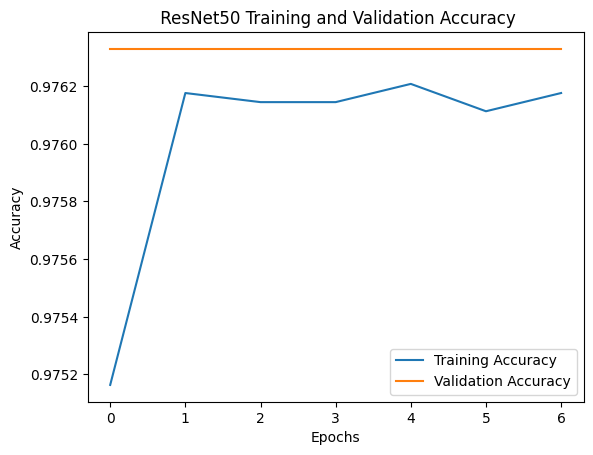

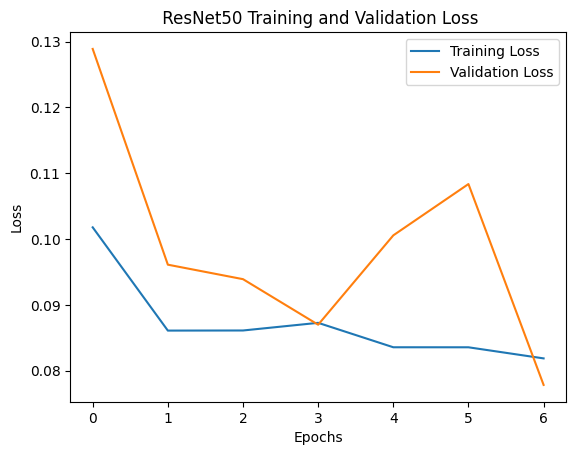

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

494/494 ━━━━━━━━━━━━━━━━━━━━ 102s 198ms/step


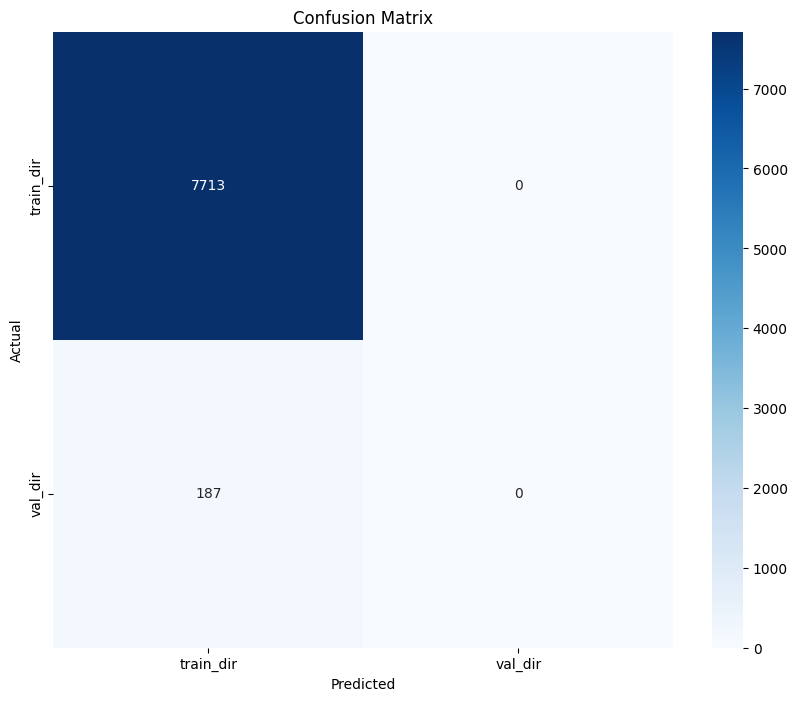

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/m

Classification Report:
               precision    recall  f1-score   support

   train_dir       0.98      1.00      0.99      7713
     val_dir       0.00      0.00      0.00       187

    accuracy                           0.98      7900
   macro avg       0.49      0.50      0.49      7900
weighted avg       0.95      0.98      0.96      7900

Accuracy: 97.63%
Precision: 95.32%
Recall: 97.63%
F1 Score: 96.46%


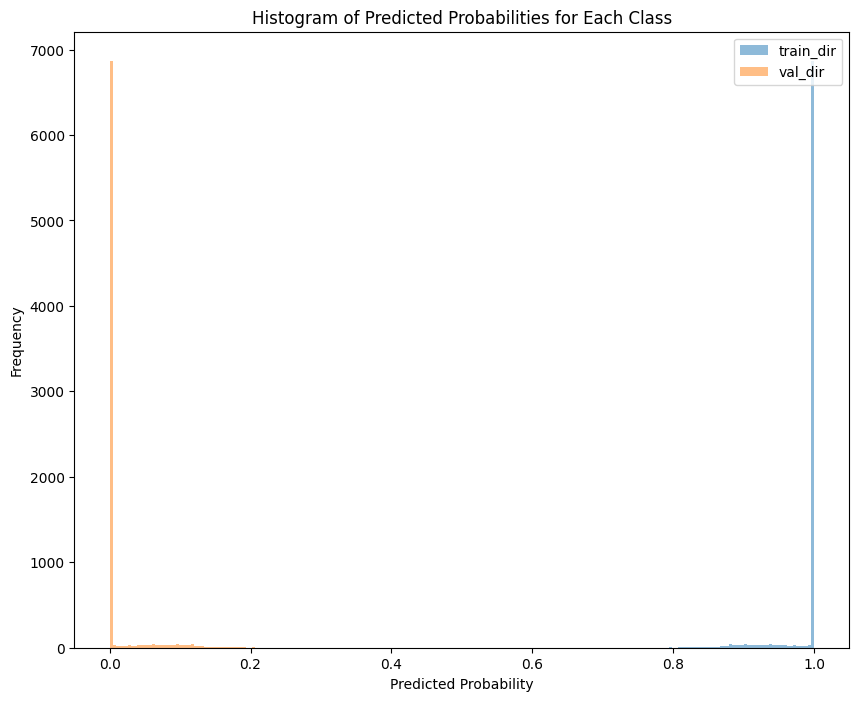

In [17]:
for model_name, base_model in base_models.items():
    print(f"Training {model_name}")
    # Change the file extension to '.keras'
    check_point = ModelCheckpoint(f'{model_name}_best_model.keras', save_best_only=True)
    earlystopping = EarlyStopping(patience=5, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(factor=0.1, patience=3)

    for layer in base_model.layers:
        layer.trainable = False
    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(1024, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(512, activation='relu')(x)

    # Determine the number of classes in your dataset
    num_classes = train_generator.num_classes
    predictions = layers.Dense(num_classes, activation='softmax')(x)

    proposed_model = models.Model(inputs=base_model.input, outputs=predictions)
    proposed_model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['accuracy'])

    # Print model summary
    print(f"Model Summary for {model_name}:")
    proposed_model.summary()

    # Training the model
    history = proposed_model.fit(train_generator, epochs=7, validation_data=validation_generator, callbacks=[check_point, earlystopping, reduce_lr])

    # Plot training and validation accuracy
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name} Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

    # Plot training and validation loss
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    # Load the best model weights
    proposed_model.load_weights(f'{model_name}_best_model.keras')


    # Download the best model
    files.download(f'{model_name}_best_model.keras')



    # Predictions
y_pred = proposed_model.predict(validation_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = validation_generator.classes

# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=validation_generator.class_indices, yticklabels=validation_generator.class_indices)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
class_report = classification_report(y_true, y_pred_classes, target_names=list(validation_generator.class_indices.keys()))
print("Classification Report:\n", class_report)

# Accuracy
accuracy = accuracy_score(y_true, y_pred_classes)
print(f'Accuracy: {accuracy * 100:.2f}%')

# Precision, Recall, F1 Score
precision = precision_score(y_true, y_pred_classes, average='weighted')
recall = recall_score(y_true, y_pred_classes, average='weighted')
f1 = f1_score(y_true, y_pred_classes, average='weighted')

print(f'Precision: {precision * 100:.2f}%')
print(f'Recall: {recall * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%')

# Histogram of predicted probabilities
plt.figure(figsize=(10, 8))
for i, class_name in enumerate(validation_generator.class_indices):
    plt.hist(y_pred[:, i], bins=50, alpha=0.5, label=class_name)
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.title('Histogram of Predicted Probabilities for Each Class')
plt.legend(loc='upper right')
plt.show()



